# Impute Missing Data and Research Question
- Author: Bryan Bravo
- Created: 2026-04-07
## Research Question:
Using crude oil spot prices, the Liner Shipping Connectivity Index (LSCI), global political violence events, and a geopolitical risk index, can we accurately estimate a country's foreign exchange (FX) reserves and its imports of goods and services using a Random Forest Regressor?

### Selected Variables
#### Relative (Target) Variable:
- **fx_reserves**: Continuous Variable
- **imports_good_service**: Continuous Variable

#### Explanatory Variables:


## Import Libraries

In [1]:
import os
import sys

os.chdir("C:/Users/bravo/OneDrive/bravo_projects/MLProject/StraitofHormuzResearch")
# Set JAVA_HOME before importing PySpark and use findspark
os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-22'  # May need to remove or update in cloud environment.
import findspark
findspark.init()

import requests
import pandas as pd
import numpy as np
import json
import pyspark
from datetime import datetime as dt
from dateutil.relativedelta import relativedelta
from functools import reduce
from pyspark.sql import (
    functions as F,
    Window as W,
    types as T,
    SparkSession,
    DataFrame
)

# Visualize data for joined dataframes.
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns


# api keys and other hardcoded values for the Strait of Hormuz Research project.
# Note: In a production environment, these should be stored securely and not hardcoded.
import hardcoded_keys # Note: This file is added to .gitignore to prevent accidental commits of sensitive information.

import proj_vars

### Initialize Spark Session


In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BusinessPlanAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.hadoop.io.native.lib.available", "false") \
    .config("spark.sql.parquet.nativeio.enabled", "false") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


## Variables

In [3]:
end_date = (dt.now().replace(day=1) - relativedelta(days=1)).strftime("%Y-%m-%d")
# in_path = 's3a://ml-project-s3-bronze/input_folder/'
in_path = 'processed_datasets/'
out_path = 'processed_datasets/'


# Query

In [33]:
# Import dataset
joined_df = spark.read.csv(in_path + 'joined_input.csv', header=True, inferSchema=True)
joined_df = joined_df.withColumn('date', F.to_date(F.col('date'), 'yyyyMMdd'))

In [35]:
# Create separate dataframes for each country
country_list = joined_df.select(F.col('country')).distinct().toPandas()['country'].tolist()
country_dct = {f"{country}_df": joined_df.filter(F.col('country').contains(country)) 
               for country in country_list}
[*country_dct.keys()]

['brazil_df',
 'canada_df',
 'japan_df',
 'china_df',
 'australia_df',
 'germany_df',
 'india_df',
 'france_df',
 'italy_df',
 'south_africa_df',
 'russia_df',
 'south_korea_df',
 'turkiye_df',
 'united_kingdom_df',
 'mexico_df',
 'united_states_df']

In [37]:
joined_df.toPandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60276 entries, 0 to 60275
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      60276 non-null  int32  
 1   month                     60276 non-null  int32  
 2   country                   60276 non-null  object 
 3   date                      60276 non-null  object 
 4   interest_rate             60276 non-null  float64
 5   fx_rate                   60276 non-null  float64
 6   brent_dollars_per_barrel  60276 non-null  float64
 7   wti_dollars_per_barrel    60276 non-null  float64
 8   events                    60276 non-null  int32  
 9   cpi                       60276 non-null  float64
 10  gpr_index                 60276 non-null  float64
 11  lsci                      60276 non-null  float64
 12  fx_reserves               55596 non-null  float64
 13  imports_good_service      55596 non-null  float64
dtypes: flo

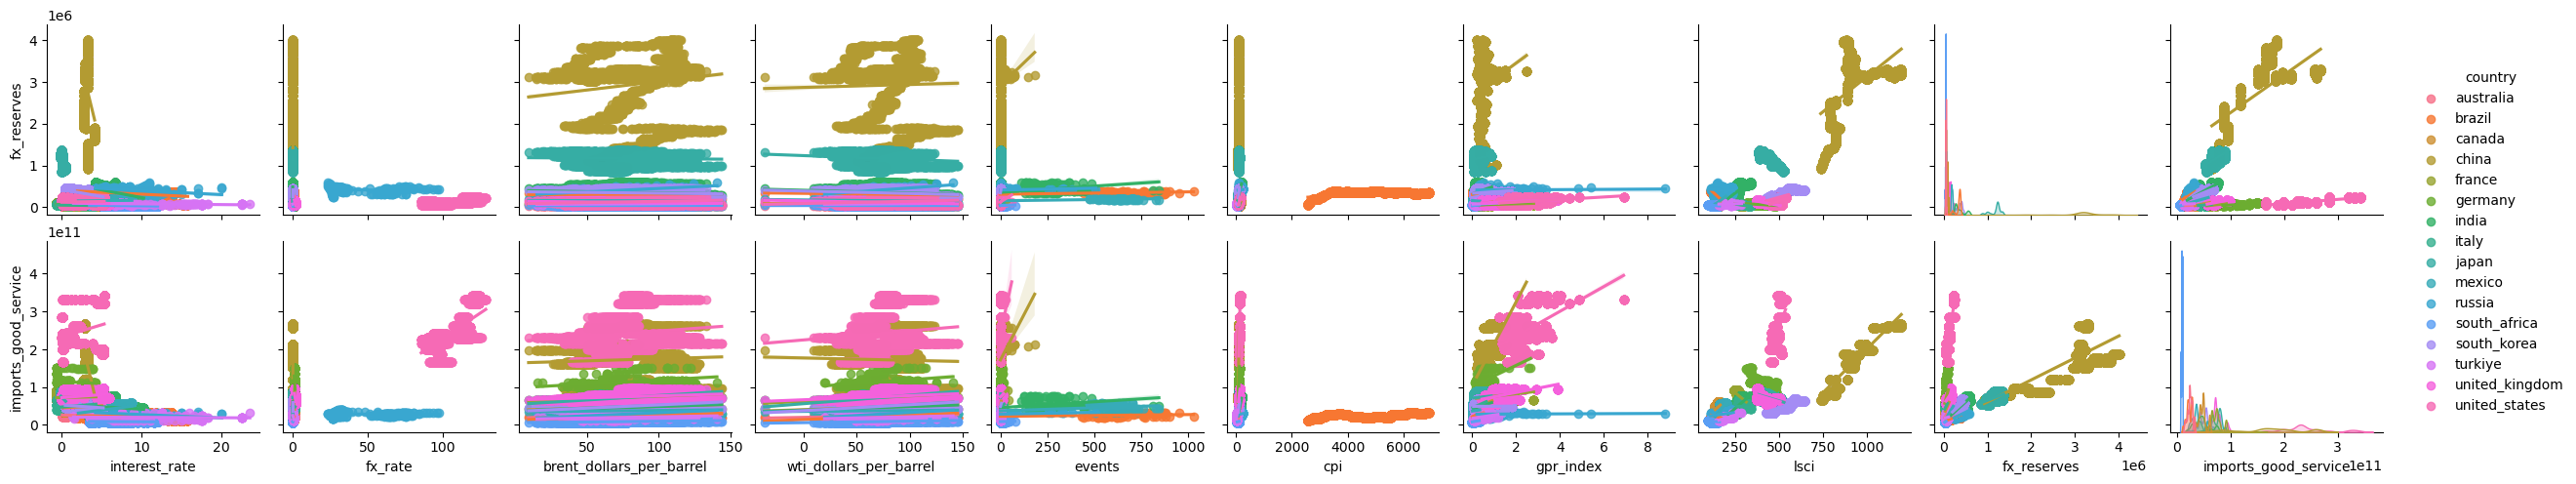

In [43]:
sns.pairplot(joined_df.toPandas().drop(columns=['date', 'year', 'month']), hue='country', 
             y_vars=['fx_reserves', 'imports_good_service'], kind='reg')

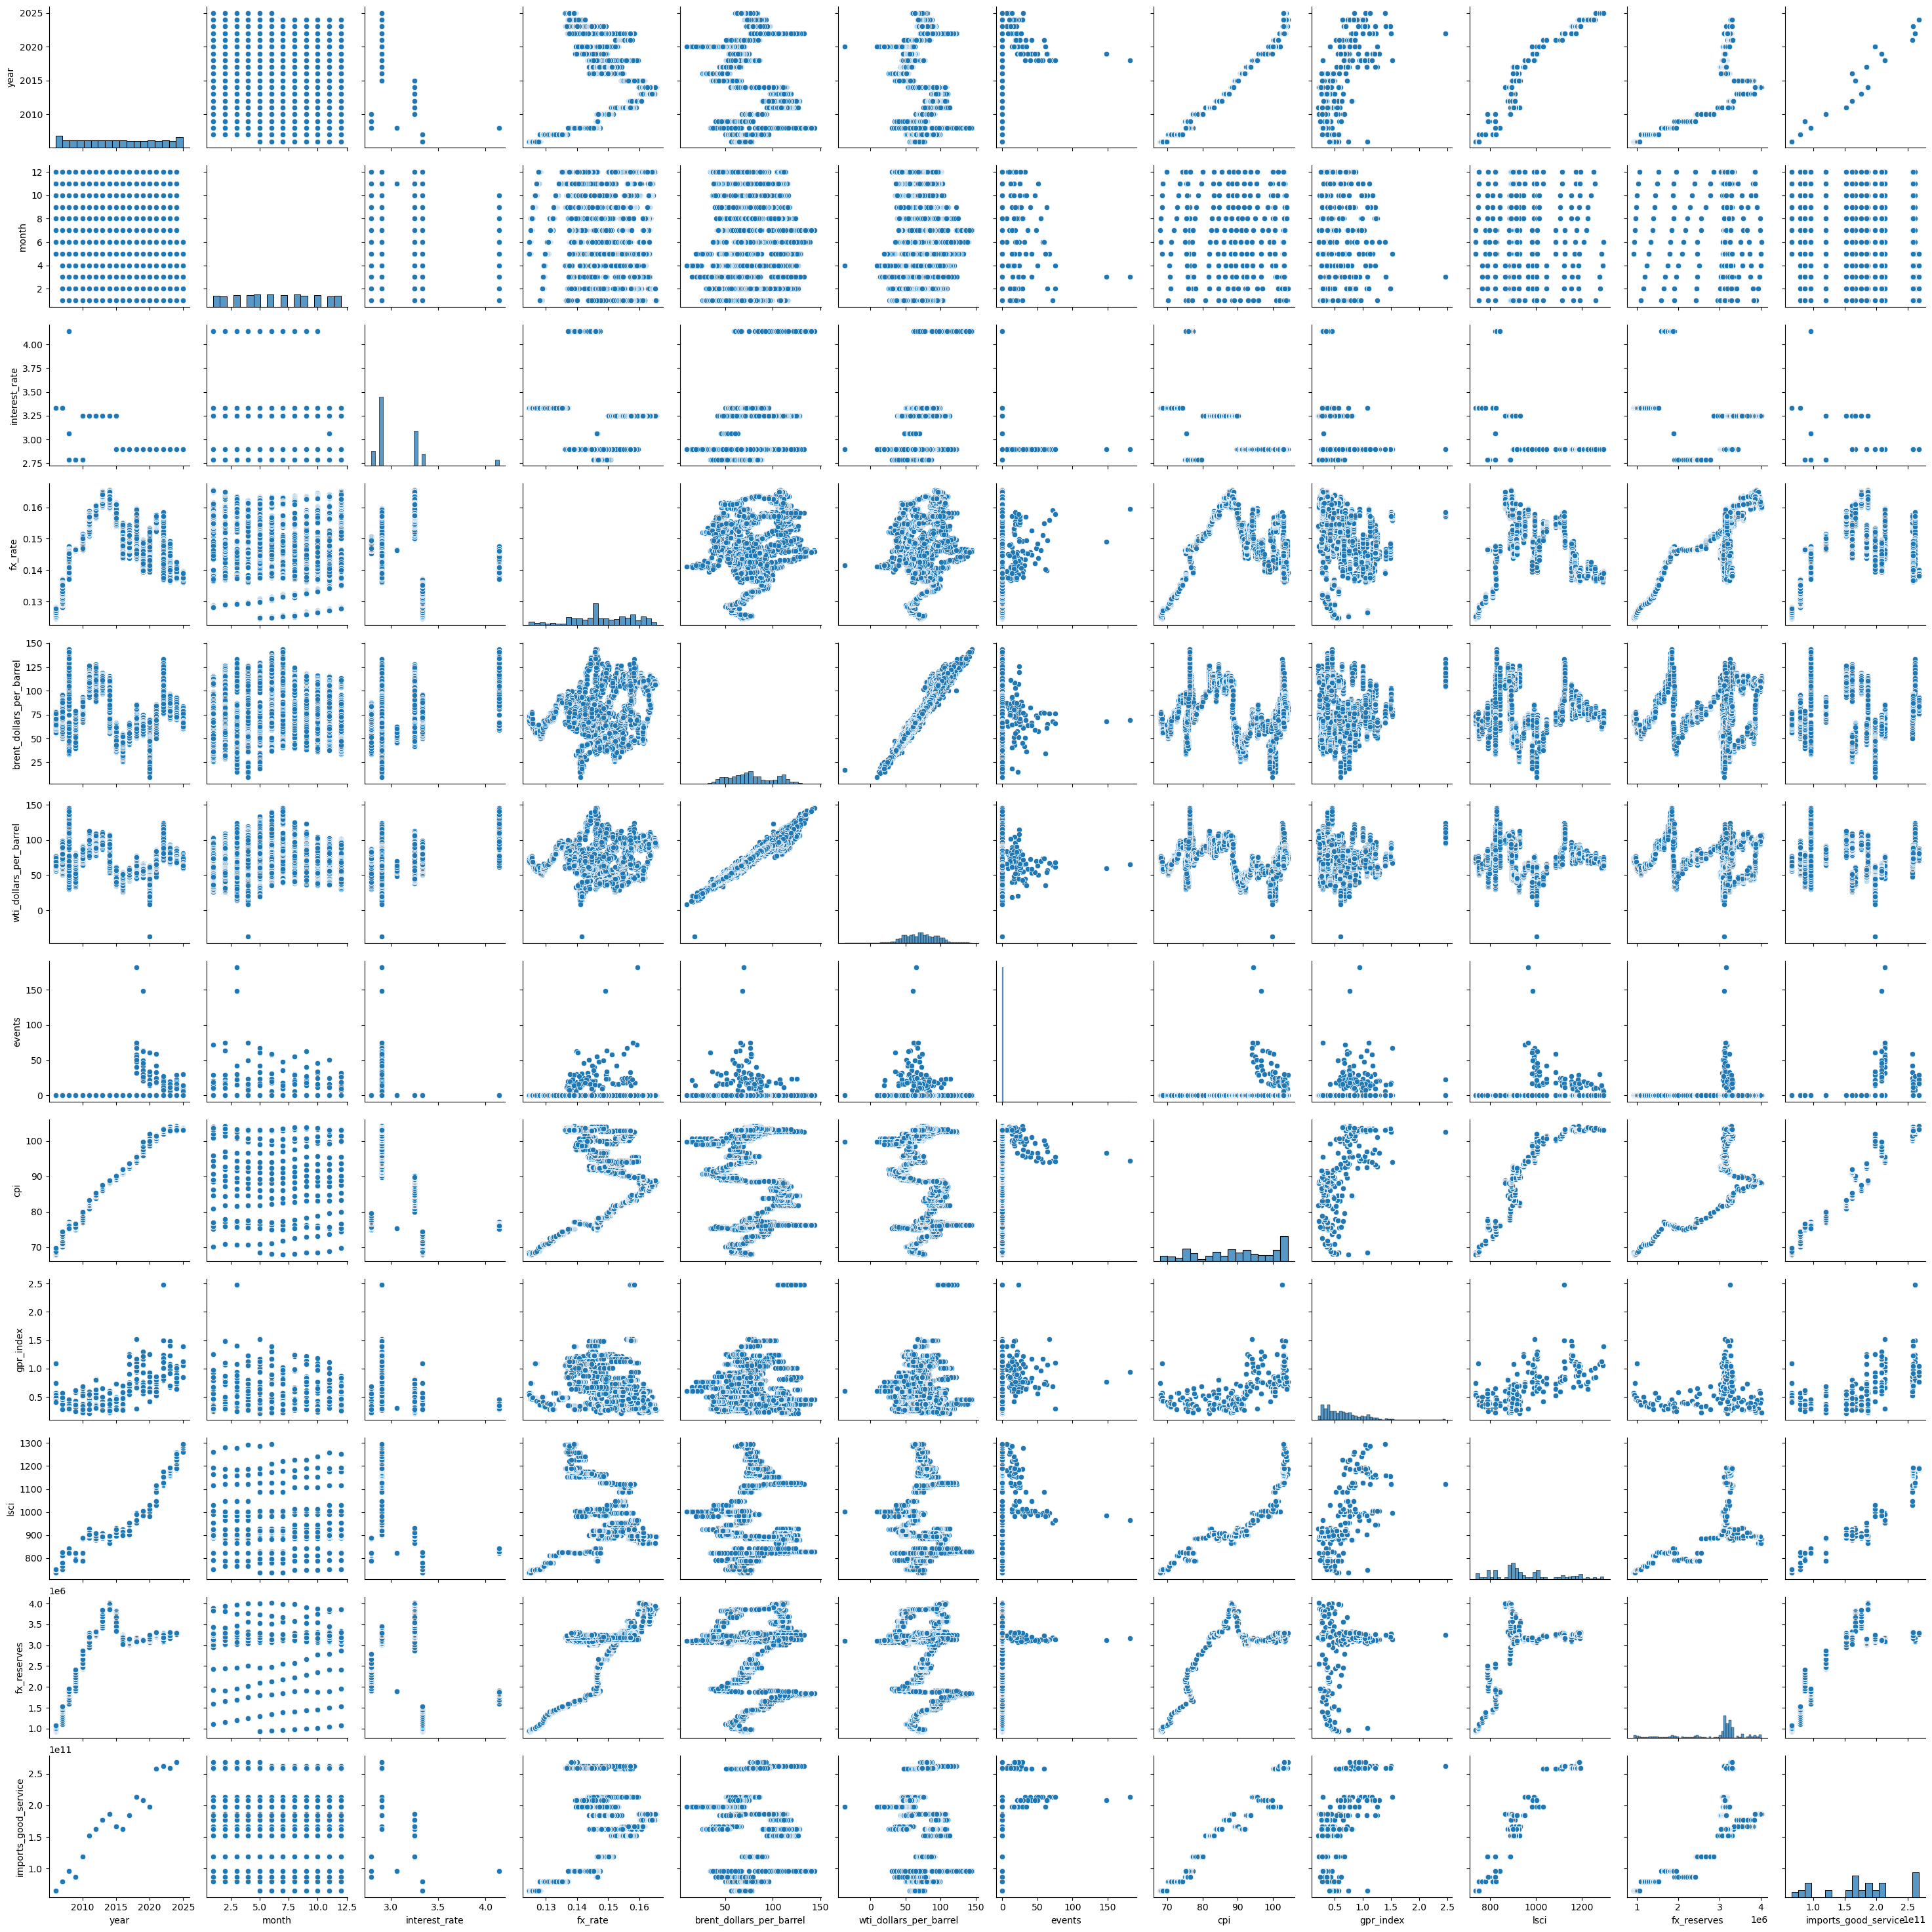

In [41]:
sns.pairplot(country_dct['china_df'].toPandas().drop(columns=['date', 'country']), )